In [1]:
import os
import pickle
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
import statsmodels.stats.multitest
from tqdm import tqdm

import pyBigWig
import pyranges1 as pr
import datasources
from knots_tools import *

In [2]:
ccds_pr, _ = load_cknots_base_data()

# Compartments

In [3]:
def load_bigwig_compartments(path, resolution = 5_000):
    bw = pyBigWig.open(path)
    results = []
    ccds_ = ccds_pr.query('dataset == "GM12878"').copy().set_index(['Chromosome', 'ccd_id']).sort_index()
    for chrom, size in bw.chroms().items():
        if chrom == 'chrY':
            continue
        ccd_data = ccds_.loc[chrom]
        for ccd_id, row in tqdm(ccd_data.iterrows(), total=len(ccd_data), desc=f'{chrom}'):        
            ccd_s = row['Start']
            ccd_e = row['End']
            prev_s = None
            for s, e, v in bw.intervals(chrom, ccd_s - resolution, ccd_e + resolution):
                if prev_s is None:
                    prev_s = s - resolution
                while s < prev_s + resolution:
                    prev_s += resolution
                    results.append((chrom, ccd_id, prev_s, prev_s + resolution, np.nan))
                results.append((chrom, ccd_id, s, e, v))
                prev_s = s
    bw.close()
    res_df = pd.DataFrame.from_records(results, columns=['Chromosome', 'ccd_id', 'Start', 'End', 'value'])
    res_df["zscore"] = res_df.groupby("Chromosome").value.transform(scipy.stats.zscore)
    return res_df

In [4]:
e1df = load_bigwig_compartments("./data/compartments/GM12878_compartments_4DNFIDO8B3C6.bw")
print(e1df.value.min(), e1df.value.max())

chrX: 100%|███████████████████████████████████████████████████| 51/51 [00:00<00:00, 11627.41it/s]


-5.542346477508545 6.428318977355957


In [5]:
def count_boundaries(x: pd.Series):
    if len(x) < 2:
        return 0
    prev = x.iat[0]
    n = 0
    for v in x.iloc[1:]:
        if np.isnan(v):
            continue
        if (v > 0) != (prev > 0):
            n += 1
        prev = v
    return n

def calc_boundary_stats(comp_df, roi_df, signal_col='value'):
    comp_bounds = comp_df.groupby(['Chromosome', 'ccd_id'])[signal_col].aggregate(count_boundaries).to_frame('n_bounds')
    comp_bounds['has_bounds'] = comp_bounds.n_bounds > 1
    comp_bounds = pd.merge(comp_bounds, roi_df, on=['Chromosome', 'ccd_id'], how='left')
    comp_bounds['n_bounds_per_kb'] = comp_bounds.n_bounds / (comp_bounds.length / 1000)
    return comp_bounds

bounds = calc_boundary_stats(e1df, ccds_pr.query('dataset == "GM12878"'))
bound_clip = bounds[bounds.length < 2e7]

compartment    A    B  Mixed
has_minors                  
False        941  357    909
True          64   39    154
Chi-square statistic: 36.6224
p-value: 0.000000
Degrees of freedom: 2

Expected counts:
compartment           A           B       Mixed
has_minors                                     
False        900.176542  354.696429  952.127029
True         104.823458   41.303571  110.872971
compartment          A          B      Mixed
has_minors                                  
False        42.637064  16.175804  41.187132
True         24.902724  15.175097  59.922179


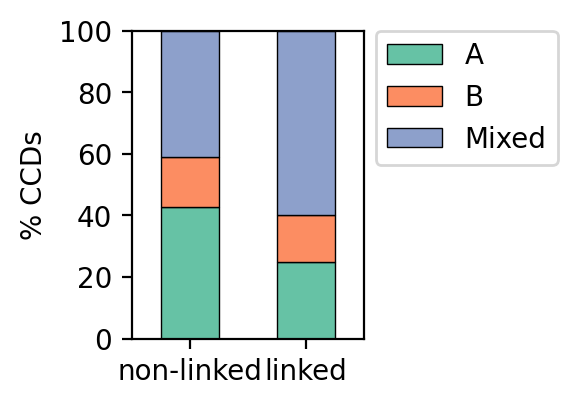

In [6]:
ct = e1df.groupby(['Chromosome', 'ccd_id']).agg(
    n_A=('value', lambda x: (x > 0).sum()),
    n_B=('value', lambda x: (x < 0).sum())
).reset_index()
ct['compartment'] = 'Undefined'
ct.loc[(ct.n_A > 0) & (ct.n_B == 0), 'compartment'] = 'A'
ct.loc[(ct.n_A == 0) & (ct.n_B > 0), 'compartment'] = 'B'
ct.loc[(ct.n_A > 0) & (ct.n_B > 0), 'compartment'] = 'Mixed'
ct = ct.merge(ccds_pr.query('dataset == "GM12878"'), on=['Chromosome', 'ccd_id'], how='left')
tmp = ct.groupby(['has_minors', 'compartment']).size().unstack().fillna(0).astype(int).iloc[:,:-1]
print(tmp)

chi2, p, dof, expected = scipy.stats.chi2_contingency(tmp)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p:.6f}")
print(f"Degrees of freedom: {dof}")

expected_df = pd.DataFrame(expected, index=tmp.index, columns=tmp.columns)
print("\nExpected counts:")
print(expected_df)

tmp2 = tmp / tmp.sum(axis=1).values.reshape(-1, 1) * 100
print(tmp2)
plt.figure(figsize=(1.5, 2), dpi=200)
tmp2.plot(
    kind='bar', stacked=True, ax=plt.gca(), color=sns.color_palette('Set2', 3),
    linewidth=.5, edgecolor='black'
)
plt.gca().set_xticklabels(['non-linked', 'linked'])
plt.ylim(0, 100)
plt.xlabel('')
plt.xticks(rotation=0)
plt.ylabel('% CCDs')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.);
# plt.savefig('./results/svg/comp_lores.svg')

In [7]:
e1hrdf = load_bigwig_compartments("./data/compartments/GM12878_hires_ENCFF661LPK.bigWig")
print(e1hrdf.value.min(), e1hrdf.value.max())

chrX: 100%|████████████████████████████████████████████████████| 51/51 [00:00<00:00, 3305.20it/s]


-0.027598999440670013 0.03292499855160713


/home/michade/proj/knots/intrinsic_linking/knots_tools.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['non-linked', 'linked'])
/home/michade/proj/knots/intrinsic_linking/knots_tools.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['non-linked', 'linked'])
/home/michade/proj/knots/intrinsic_linking/knots_tools.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['non-linked', 'linked'])
/home/michade/proj/knots/intrinsic_linking/knots_tools.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['non-linked', 'linked'])


Mann-Whitney U test: statistic=222766.0000, p-value=0.000000 (data: n_bounds). Median: non-linked=0.0000, linked=1.0000
Mann-Whitney U test: statistic=243221.5000, p-value=0.000092 (data: n_bounds_per_kb). Median: non-linked=0.0000, linked=0.0014
Mann-Whitney U test: statistic=234154.5000, p-value=0.000002 (data: n_bounds). Median: non-linked=0.0000, linked=2.0000
Mann-Whitney U test: statistic=252743.5000, p-value=0.003936 (data: n_bounds_per_kb). Median: non-linked=0.0000, linked=0.0026


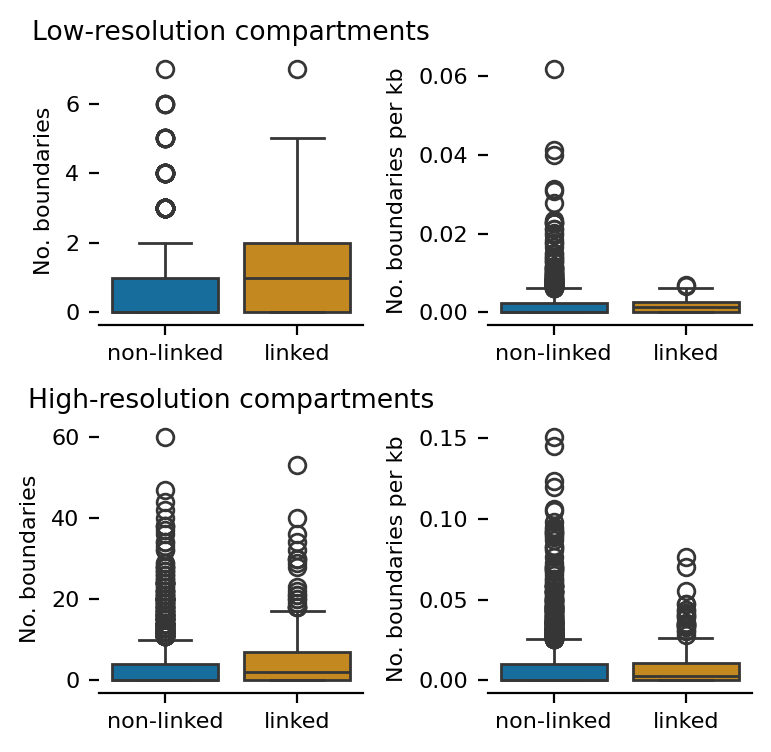

In [8]:
bounds_hr = calc_boundary_stats(e1hrdf, ccds_pr.query('dataset == "GM12878"'))

matplotlib.rcParams.update({'font.size': 8})
fig, axs = plt.subplots(
    nrows=2, ncols=2, figsize=(7.8 / 2, 3.8), dpi=200,
    sharex=False, sharey=False
)
bound_hr_clip = bounds_hr[bounds_hr.length < 2e7]

compare_boxplot(bound_clip, axs[0, 0], y='n_bounds', ylab='No. boundaries')
axs[0, 0].set_title('Low-resolution compartments')
compare_boxplot(bound_clip, axs[0, 1], y='n_bounds_per_kb', ylab='No. boundaries per kb')

axs[1, 0].set_title('High-resolution compartments')
compare_boxplot(bound_hr_clip, axs[1, 0], y='n_bounds', ylab='No. boundaries')
compare_boxplot(bound_hr_clip, axs[1, 1], y='n_bounds_per_kb', ylab='No. boundaries per kb')
plt.tight_layout()
# plt.savefig('./results/svg/compartments_boundaries.svg')

  Chromosome  ccd_id  n_A  n_B
0       chr1       1   66    0
1       chr1       2   11    1
2       chr1       3   41    0
3       chr1       4   30    1
4       chr1       5   10    0
compartment     A    B  Mixed
has_minors                   
False        1038  201    970
True           74   38    145
Chi-square statistic: 32.5522
p-value: 0.000000
Degrees of freedom: 2

Expected counts:
compartment         A           B       Mixed
has_minors                                   
False        996.1103  214.092052  998.797648
True         115.8897   24.907948  116.202352
compartment          A          B      Mixed
has_minors                                  
False        46.989588   9.099140  43.911272
True         28.793774  14.785992  56.420233


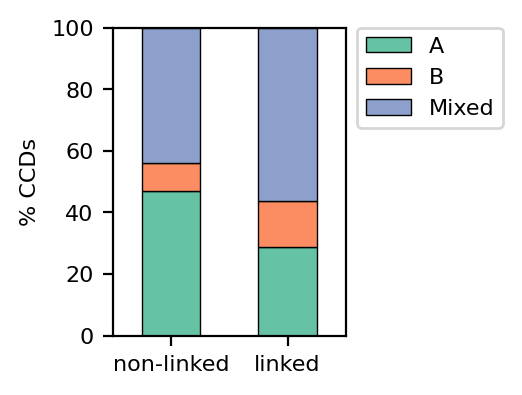

In [12]:
ct = e1hrdf.groupby(['Chromosome', 'ccd_id']).agg(
    n_A=('value', lambda x: (x > 0).sum()),
    n_B=('value', lambda x: (x < 0).sum())
).reset_index()
print(ct.head())
ct['compartment'] = 'Undefined'
ct.loc[(ct.n_A > 0) & (ct.n_B == 0), 'compartment'] = 'A'
ct.loc[(ct.n_A == 0) & (ct.n_B > 0), 'compartment'] = 'B'
ct.loc[(ct.n_A > 0) & (ct.n_B > 0), 'compartment'] = 'Mixed'
ct = ct.merge(ccds_pr.query('dataset == "GM12878"'), on=['Chromosome', 'ccd_id'], how='left')
tmp = ct.groupby(['has_minors', 'compartment']).size().unstack().fillna(0).astype(int)
print(tmp)

chi2, p, dof, expected = scipy.stats.chi2_contingency(tmp)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p:.6f}")
print(f"Degrees of freedom: {dof}")

expected_df = pd.DataFrame(expected, index=tmp.index, columns=tmp.columns)
print("\nExpected counts:")
print(expected_df)

tmp2 = tmp / tmp.sum(axis=1).values.reshape(-1, 1) * 100
print(tmp2)
plt.figure(figsize=(1.5, 2), dpi=200)
tmp2.plot(
    kind='bar', stacked=True, ax=plt.gca(), color=sns.color_palette('Set2', 3),
    linewidth=.5, edgecolor='black'
)
plt.gca().set_xticklabels(['non-linked', 'linked'])
plt.ylim(0, 100)
plt.xlabel('')
plt.xticks(rotation=0)
plt.ylabel('% CCDs')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.);
plt.savefig('./results/svg/comp_hires.svg')